# EPC04 Algoritmos de ordenacao

Implemente os seguintes algoritmos de ordenação:

1. Bubble Sort
2. Selection Sort
3. Insertion Sort
4. Merge Sort
5. Quick Sort
6. Heap Sort in place
7. Heap Sort not in place

Todos os algoritmos devem ser implementados em python sem utilizar nenhuma biblioteca externa. Eles devem receber como parâmetro uma lista de elementos e ordenar esta lista. Para que a comparação seja justa, passe a mesma lista para todos os algoritmos!!!
 
Você deve implementar também um código que gere um gráfico comparando o desempenho dos algoritmos utilizando listas com diferentes tamanhos, nos seguintes cenários:

1. lista com números aleatórios
2. lista ordenada de forma ascendente
3. lista ordenada de forma descendente

Você deve enviar o código dos algoritmos e do gráfico em um arquivo único no formato .ipypnb.

In [1]:
from typing import List

In [2]:
def swap(list: List, pos1, pos2):
    list[pos1], list[pos2] = list[pos2], list[pos1]
    return list

In [3]:
def bubble_sort(L:List):
    for i in range(len(L)-1):
        for j in range(len(L)-1-i):
            if L[j] > L[j+1]:
                swap(L, j, j+1)
    return L

In [4]:
lista = [2, 10, 1, 0, 3]

print(f"lista ordenada: {bubble_sort(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [5]:
def selection_sort(L:List)->List:
    for i in range(len(L)-1):
        for j in range(i+1, len(L)):
            if L[j] < L[i]:
                swap(L, i, j)
    return L

In [6]:
lista = [2, 10, 1, 0, 3]
print(f"lista ordenada: {selection_sort(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [7]:
def insertion_sort(L:List)->List:
    for j in range(1, len(L)):
        x = L[j]
        i = j - 1
        while i >= 0 and L[i] > x:
            L[i + 1] = L[i]
            i-=1
        L[i + 1] = x
    return L

In [8]:
lista = [2, 10, 1, 0, 3]
print(f"lista ordenada: {insertion_sort(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [9]:
def merge_sort(L):
    if len(L) <= 1:
        return L

    middle = len(L) // 2

    left = merge_sort(L[:middle])
    right = merge_sort(L[middle:])

    return merge(left, right)


def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result

In [10]:
lista = [2, 10, 1, 0, 3]
print(f"lista ordenada: {merge_sort(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [11]:
def quick_sort(A):
    if len(A) <= 1:
        return A

    p = A[0]
    L = []
    E = [p]
    R = []

    for i in range(1, len(A)):
        if A[i] < p:
            L.append(A[i])
        elif A[i] > p:
            R.append(A[i])
        else:
            E.append(A[i])

    L = quick_sort(L)
    R = quick_sort(R)

    return L + E + R

In [12]:
lista = [2, 10, 1, 0, 3]
print(f"lista ordenada: {quick_sort(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [13]:
def max_heapify(L, n, s):
    while True:
        esq = 2 * n + 1
        dir = 2 * n + 2

        maior = n

        if esq < s and L[esq] > L[maior]:
            maior = esq

        if dir < s and L[dir] > L[maior]:
            maior = dir

        if maior == n:
            break

        swap(L, n, maior)
        n = maior


print(max_heapify([6, 2, 1, 5], 0, 4))

None


In [14]:

def build_max_heap(L, s):
    ultimo_pai = (s - 2) // 2

    for n in range(ultimo_pai, -1, -1):
        max_heapify(L, n, s)

    return L

In [15]:


def heap_sort_in_place(L: List) -> List:
    build_max_heap(L, len(L))

    for s in range(len(L) - 1, 0, -1):
        swap(L, 0, s)
        max_heapify(L, 0, s)

    return L

In [16]:
lista = [2, 10, 1, 0, 3]
print(f"lista ordenada: {heap_sort_in_place(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [17]:
import heapq

def heap_sort_not_in_place(L:List)->List:
    if len(L) > 1:
        heap = L.copy()
        heapq.heapify_max(heap)

        for i in range(len(L) - 1, -1, -1):
            L[i] = heapq.heappop_max(heap)

    return L

In [18]:
lista = [2, 10, 1, 0, 3]
print(f"lista ordenada: {heap_sort_not_in_place(lista)}")

lista ordenada: [0, 1, 2, 3, 10]


In [19]:
import time
import random as py_random

DOMAIN = 1_000_000_000
py_random.seed(31)

import sys

sys.setrecursionlimit(1000000)
algorithms = [
    bubble_sort,
    selection_sort,
    insertion_sort,
    merge_sort,
    quick_sort,
    heap_sort_in_place,
    heap_sort_not_in_place
]

num_rounds = 3

sizes = [100, 500, 1000, 2000, 5000]

mapSizeToTime = {}

for algorithm in algorithms:
    for size in sizes:
        for scenario in ["random", "sorted", "reverse"]:
            key = f"{algorithm.__name__}##{size}##{scenario}"
            mapSizeToTime[key] = 0


def executionTime(L, func):
    start = time.perf_counter()
    func(L)
    end = time.perf_counter()
    return end - start


# Coleta dos tempos
for r in range(num_rounds):

    print(f"Round {r+1}")

    for size in sizes:

        # mesma lista para todos os algoritmos
        L_random = py_random.sample(range(DOMAIN), size)

        L_sorted = sorted(L_random)

        L_reverse = sorted(L_random, reverse=True)

        for algorithm in algorithms:

            mapSizeToTime[f"{algorithm.__name__}##{size}##random"] += \
                executionTime(L_random.copy(), algorithm)

            mapSizeToTime[f"{algorithm.__name__}##{size}##sorted"] += \
                executionTime(L_sorted.copy(), algorithm)

            mapSizeToTime[f"{algorithm.__name__}##{size}##reverse"] += \
                executionTime(L_reverse.copy(), algorithm)

for key in mapSizeToTime:
    mapSizeToTime[key] /= num_rounds

print("Coleta finalizada.")

Round 1


Round 2
Round 3
Coleta finalizada.


In [20]:
import pandas as pd

df = pd.DataFrame.from_dict(
    mapSizeToTime,
    orient="index",
    columns=["Time"]
)

df["Algorithm"] = [i.split("##")[0] for i in df.index]
df["Size"] = [int(i.split("##")[1]) for i in df.index]
df["Scenario"] = [i.split("##")[2] for i in df.index]

df

,Time,Algorithm,Size,Scenario
bubble_sort##100##random,0.000257,bubble_sort,100,random
bubble_sort##100##sorted,0.000179,bubble_sort,100,sorted
bubble_sort##100##reverse,0.000333,bubble_sort,100,reverse
bubble_sort##500##random,0.007677,bubble_sort,500,random
bubble_sort##500##sorted,0.004564,bubble_sort,500,sorted
...,...,...,...,...
heap_sort_not_in_place##2000##sorted,0.000263,heap_sort_not_in_place,2000,sorted
heap_sort_not_in_place##2000##reverse,0.000293,heap_sort_not_in_place,2000,reverse
heap_sort_not_in_place##5000##random,0.001131,heap_sort_not_in_place,5000,random
heap_sort_not_in_place##5000##sorted,0.000844,heap_sort_not_in_place,5000,sorted


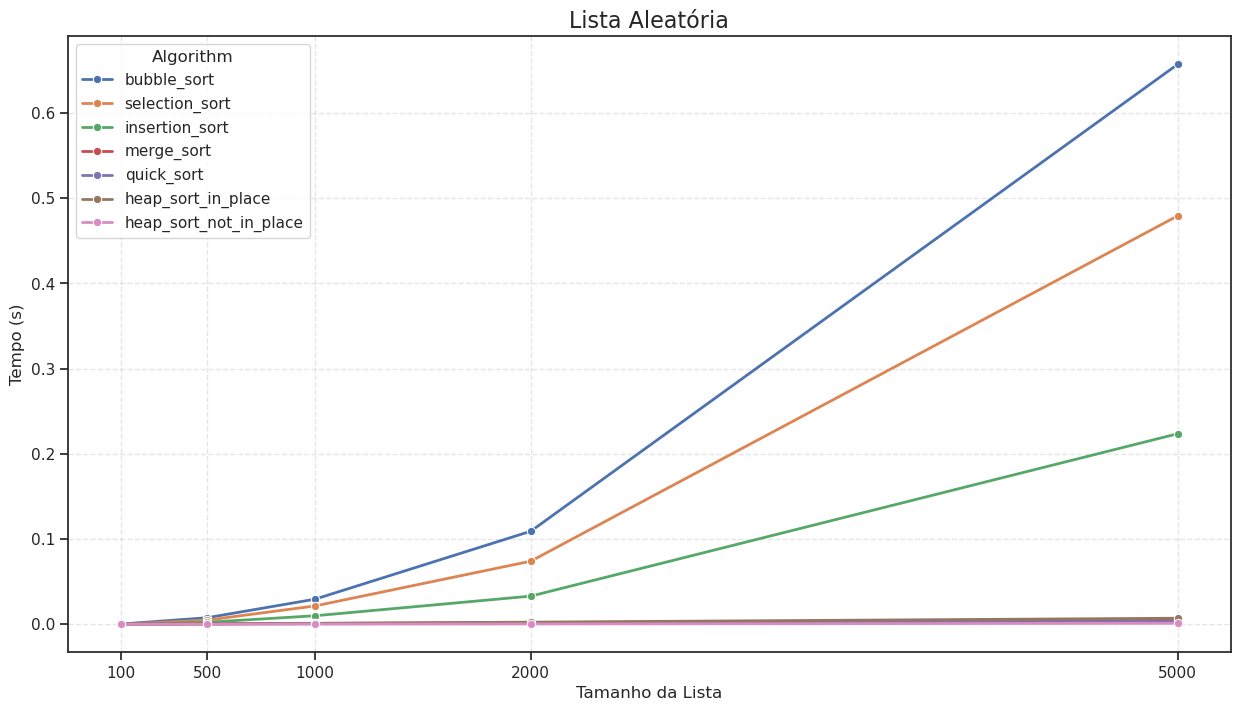

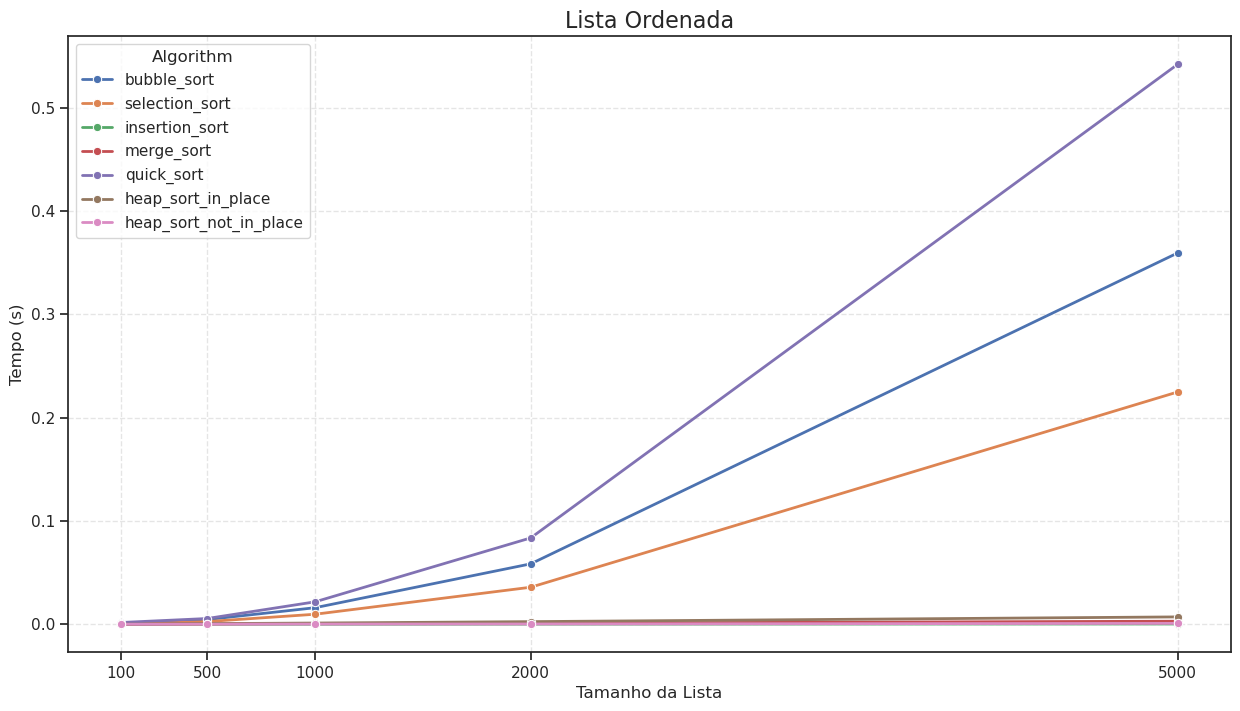

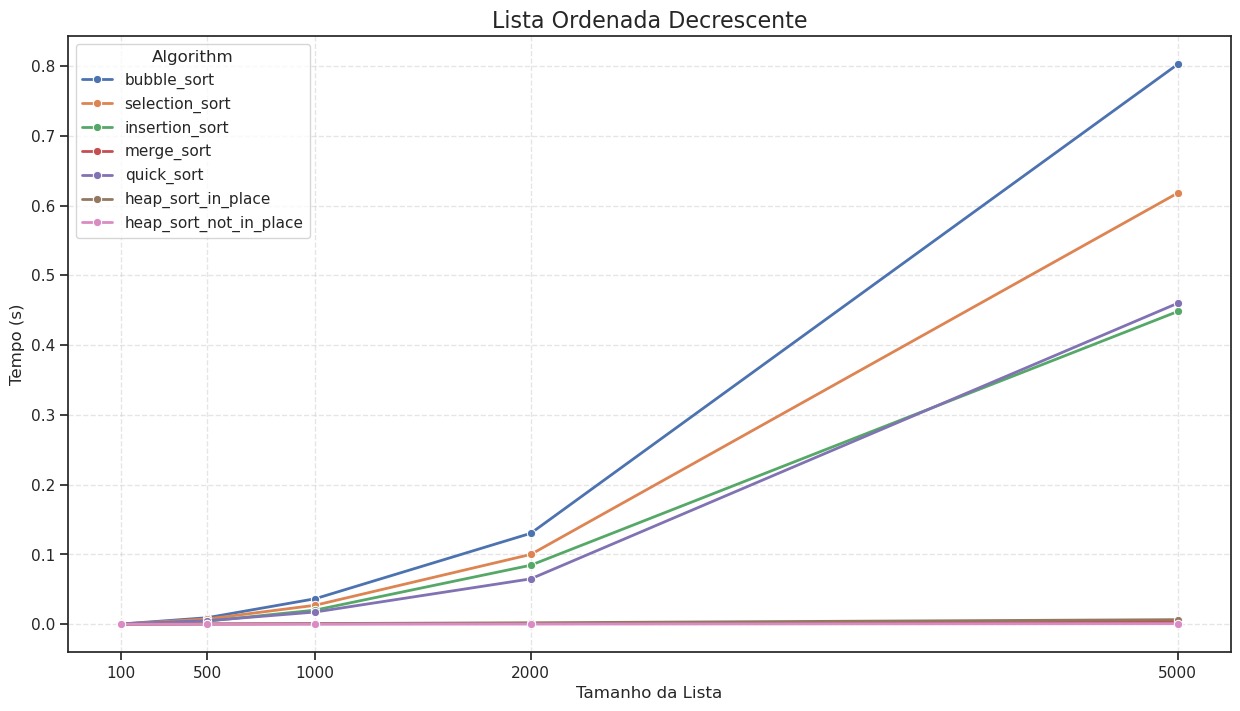

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1, style="ticks", rc={"lines.linewidth": 2})

for scenario in ["random", "sorted", "reverse"]:

    plt.figure(figsize=(15,8))

    g = sns.lineplot(
        data=df[df["Scenario"] == scenario],
        x="Size",
        y="Time",
        hue="Algorithm",
        marker="o"
    )

    g.set(xticks=sizes)

    if scenario == "random":
        titulo = "Lista Aleatória"
    elif scenario == "sorted":
        titulo = "Lista Ordenada"
    else:
        titulo = "Lista Ordenada Decrescente"

    g.set_title(titulo, fontsize=16)
    g.set_xlabel("Tamanho da Lista")
    g.set_ylabel("Tempo (s)")

    plt.grid(True, ls="--", alpha=0.5)
    plt.show()